# Análisis de Series Temporales - Barcelona Housing

**Fecha**: 2026-01-06  
**Autor**: Barcelona Housing Demographics Analyzer  
**Período**: 2012-2025 (14 años)

Este notebook analiza la evolución temporal de precios de vivienda en Barcelona, identifica tendencias y realiza forecasting.

## Contenido
1. [Setup](#1-setup)
2. [Análisis de Tendencias](#2-tendencias)
3. [Puntos de Inflexión](#3-inflexion)
4. [Análisis por Barrio](#4-barrios)
5. [Forecasting](#5-forecasting)
6. [Análisis de Volatilidad](#6-volatilidad)
7. [Impacto COVID-19](#7-covid)
8. [Conclusiones](#8-conclusiones)

## 1. Setup <a id='1-setup'></a>

In [1]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12

# Add project root to path
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.database import DatabaseManager

print("✅ Imports completados")

✅ Imports completados


In [2]:
# Conectar a la base de datos
db_manager = DatabaseManager()
conn = db_manager.get_connection()

print("✅ Conexión establecida")

✅ Conexión establecida


In [3]:
# Cargar datos de precios (2012-2025)
df_precios = pd.read_sql("""
    SELECT 
        p.anio,
        p.barrio_id,
        b.barrio_nombre,
        b.distrito_nombre,
        p.precio_m2_venta
    FROM fact_precios p
    JOIN dim_barrios b ON p.barrio_id = b.barrio_id
    WHERE p.precio_m2_venta IS NOT NULL
    ORDER BY p.anio, b.barrio_nombre
""", conn)

print(f"📊 Registros cargados: {len(df_precios):,}")
print(f"📅 Período: {df_precios['anio'].min()} - {df_precios['anio'].max()}")
print(f"📍 Barrios: {df_precios['barrio_nombre'].nunique()}")

df_precios.head()

📊 Registros cargados: 5,492
📅 Período: 2012 - 2025
📍 Barrios: 73


,anio,barrio_id,barrio_nombre,distrito_nombre,precio_m2_venta
0,2012,34,Can Baró,Horta-Guinardó,2869.166748
1,2012,34,Can Baró,Horta-Guinardó,1875.800049
2,2012,34,Can Baró,Horta-Guinardó,2869.166748
3,2012,49,Canyelles,Nou Barris,1484.062500
4,2012,49,Canyelles,Nou Barris,1484.062500


## 2. Análisis de Tendencias <a id='2-tendencias'></a>

In [4]:
# Calcular precio medio por año
precio_anual = df_precios.groupby('anio')['precio_m2_venta'].agg(['mean', 'median', 'std', 'count']).reset_index()

print("📊 Evolución de Precios Anuales\n")
print(precio_anual.to_string())

# Calcular tasa de crecimiento anual
precio_anual['crecimiento_pct'] = precio_anual['mean'].pct_change() * 100

print(f"\n📈 Crecimiento Promedio Anual: {precio_anual['crecimiento_pct'].mean():.2f}%")
print(f"📈 Crecimiento Total 2012-2025: {((precio_anual.iloc[-1]['mean'] - precio_anual.iloc[0]['mean']) / precio_anual.iloc[0]['mean'] * 100):.2f}%")

📊 Evolución de Precios Anuales

    anio         mean       median          std  count
0   2012  2313.196741  2214.760498   694.380452    203
1   2013  2219.118733  2051.000000   815.672385    249
2   2014  2298.525731  2141.846191   913.941040    417
3   2015  2614.035907  2419.644043   960.976714    477
4   2016  2674.058142  2501.701172  1059.768458    425
5   2017  3154.294744  3025.335938  1172.550542    417
6   2018  3403.982702  3335.082520  1175.608072    416
7   2019  3453.094132  3286.000000  1155.255131    421
8   2020  3396.260949  3329.686768  1161.695105    424
9   2021  3386.316619  3342.929932  1088.933463    419
10  2022  3539.319294  3418.107910  1157.217461    425
11  2023  3607.953721  3463.173218  1205.994166    418
12  2024  3862.322236  3784.000000  1243.101479    423
13  2025  4118.360743  4120.906982  1231.659224    358

📈 Crecimiento Promedio Anual: 4.70%
📈 Crecimiento Total 2012-2025: 78.04%


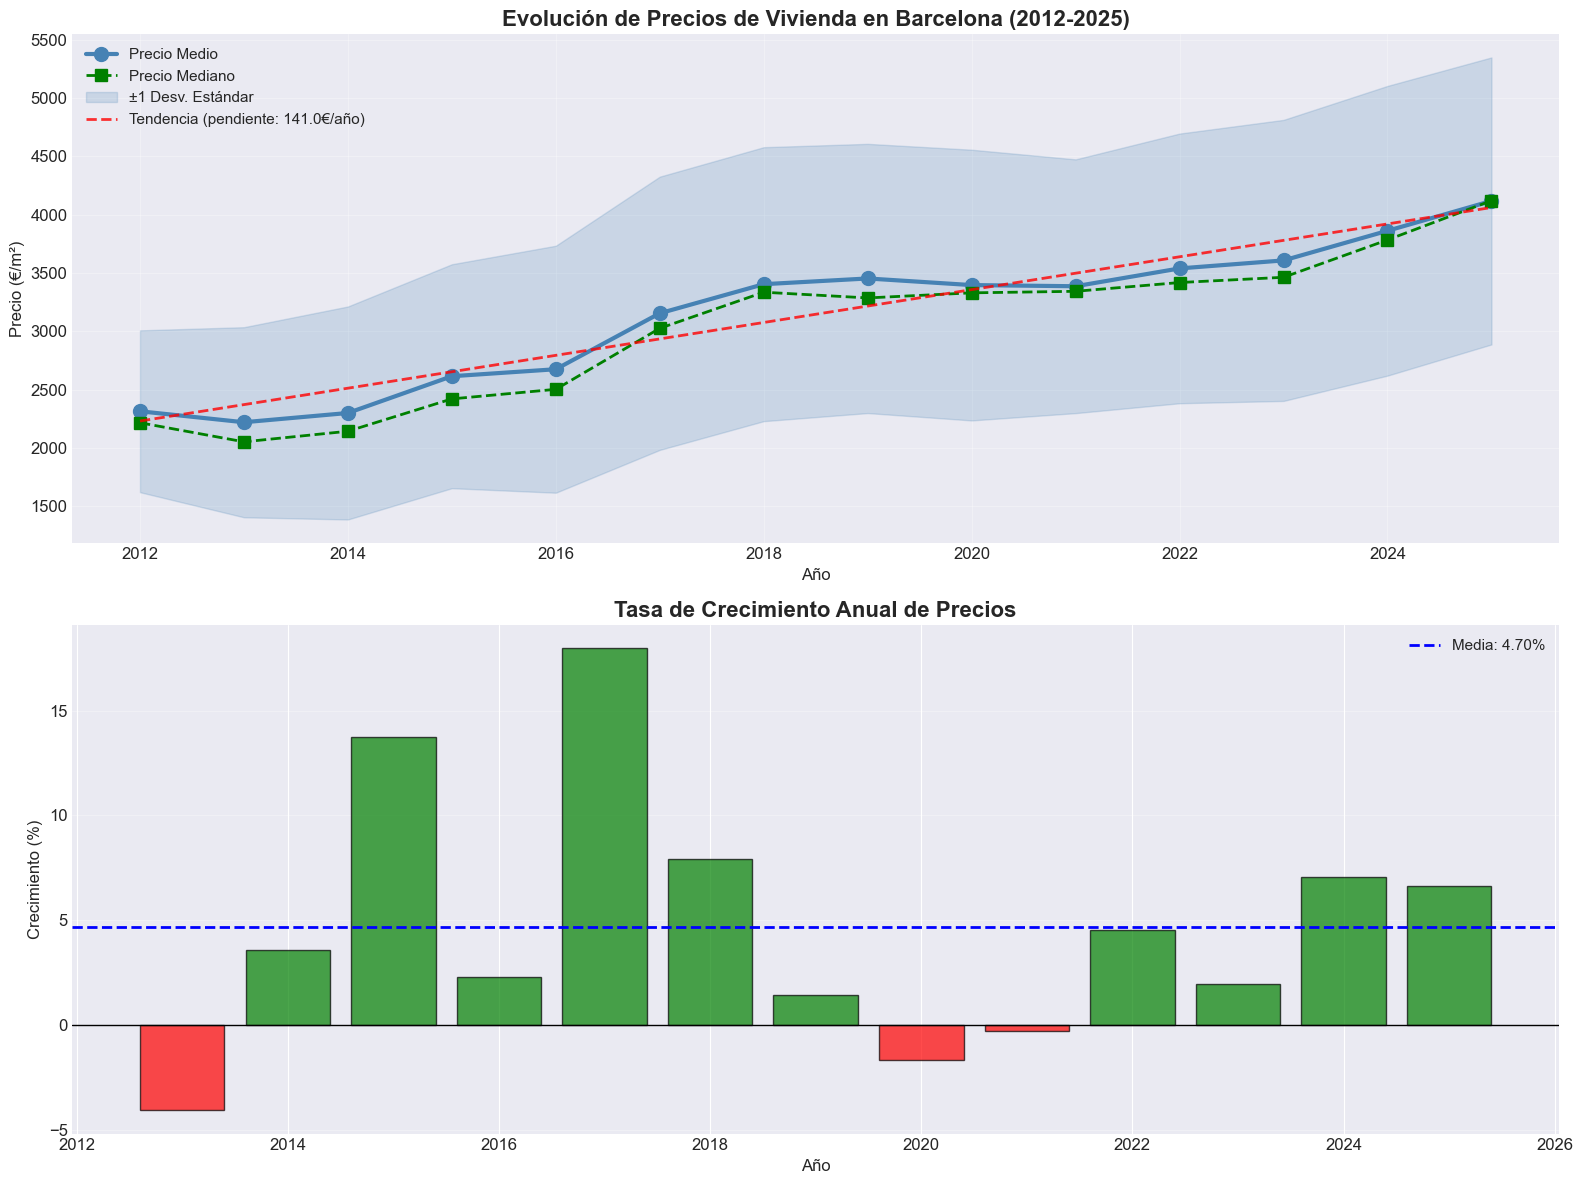

In [5]:
# Visualización de tendencia
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Gráfico 1: Evolución de precios
axes[0].plot(precio_anual['anio'], precio_anual['mean'], marker='o', linewidth=3, markersize=10, 
            color='steelblue', label='Precio Medio')
axes[0].plot(precio_anual['anio'], precio_anual['median'], marker='s', linewidth=2, markersize=8,
            color='green', label='Precio Mediano', linestyle='--')
axes[0].fill_between(precio_anual['anio'], 
                     precio_anual['mean'] - precio_anual['std'],
                     precio_anual['mean'] + precio_anual['std'],
                     alpha=0.2, color='steelblue', label='±1 Desv. Estándar')

# Añadir línea de tendencia
z = np.polyfit(precio_anual['anio'], precio_anual['mean'], 1)
p = np.poly1d(z)
axes[0].plot(precio_anual['anio'], p(precio_anual['anio']), "r--", 
            linewidth=2, alpha=0.8, label=f'Tendencia (pendiente: {z[0]:.1f}€/año)')

axes[0].set_xlabel('Año', fontsize=12)
axes[0].set_ylabel('Precio (€/m²)', fontsize=12)
axes[0].set_title('Evolución de Precios de Vivienda en Barcelona (2012-2025)', 
                 fontsize=16, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Gráfico 2: Tasa de crecimiento anual
colors = ['green' if x > 0 else 'red' for x in precio_anual['crecimiento_pct'].fillna(0)]
axes[1].bar(precio_anual['anio'], precio_anual['crecimiento_pct'], color=colors, edgecolor='black', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=precio_anual['crecimiento_pct'].mean(), color='blue', linestyle='--', 
               linewidth=2, label=f'Media: {precio_anual["crecimiento_pct"].mean():.2f}%')
axes[1].set_xlabel('Año', fontsize=12)
axes[1].set_ylabel('Crecimiento (%)', fontsize=12)
axes[1].set_title('Tasa de Crecimiento Anual de Precios', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Puntos de Inflexión <a id='3-inflexion'></a>

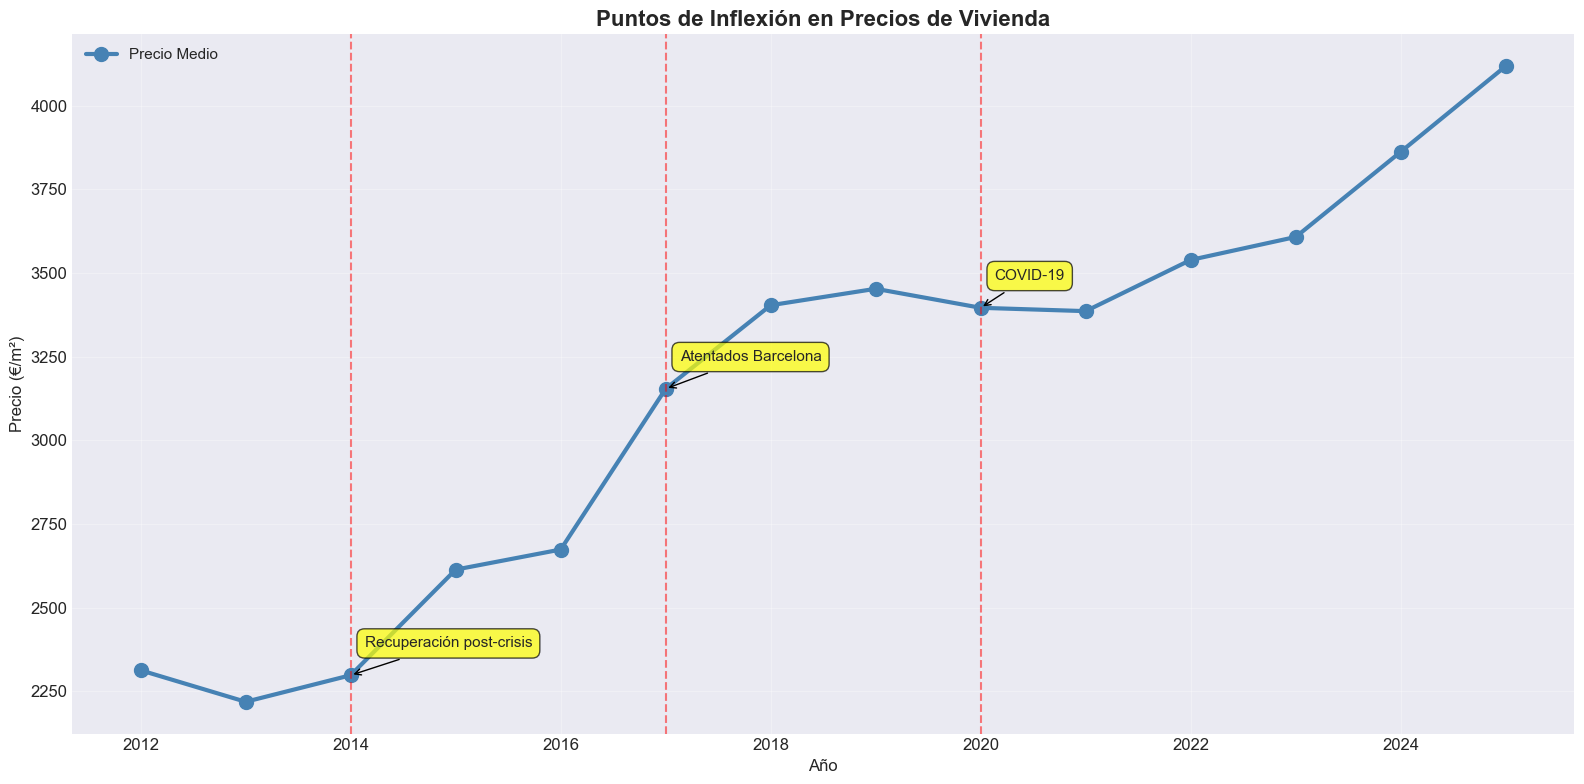


📊 Análisis de Impacto de Eventos

2020 - COVID-19:
  Crecimiento: -1.65%

2017 - Atentados Barcelona:
  Crecimiento: 17.96%

2014 - Recuperación post-crisis:
  Crecimiento: 3.58%



In [6]:
# Identificar puntos de inflexión (cambios significativos)
precio_anual['cambio_absoluto'] = precio_anual['mean'].diff()
precio_anual['aceleracion'] = precio_anual['crecimiento_pct'].diff()

# Eventos importantes
eventos = {
    2020: 'COVID-19',
    2017: 'Atentados Barcelona',
    2014: 'Recuperación post-crisis',
}

# Visualización de puntos de inflexión
plt.figure(figsize=(16, 8))

plt.plot(precio_anual['anio'], precio_anual['mean'], marker='o', linewidth=3, 
        markersize=10, color='steelblue', label='Precio Medio')

# Marcar eventos
for year, evento in eventos.items():
    if year in precio_anual['anio'].values:
        precio = precio_anual[precio_anual['anio'] == year]['mean'].values[0]
        plt.axvline(x=year, color='red', linestyle='--', alpha=0.5)
        plt.annotate(evento, xy=(year, precio), xytext=(10, 20),
                    textcoords='offset points', fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio (€/m²)', fontsize=12)
plt.title('Puntos de Inflexión en Precios de Vivienda', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de impacto
print("\n📊 Análisis de Impacto de Eventos\n")
for year, evento in eventos.items():
    if year in precio_anual['anio'].values and year > precio_anual['anio'].min():
        idx = precio_anual[precio_anual['anio'] == year].index[0]
        if idx > 0:
            cambio = precio_anual.loc[idx, 'crecimiento_pct']
            print(f"{year} - {evento}:")
            print(f"  Crecimiento: {cambio:.2f}%")
            print()

## 4. Análisis por Barrio <a id='4-barrios'></a>

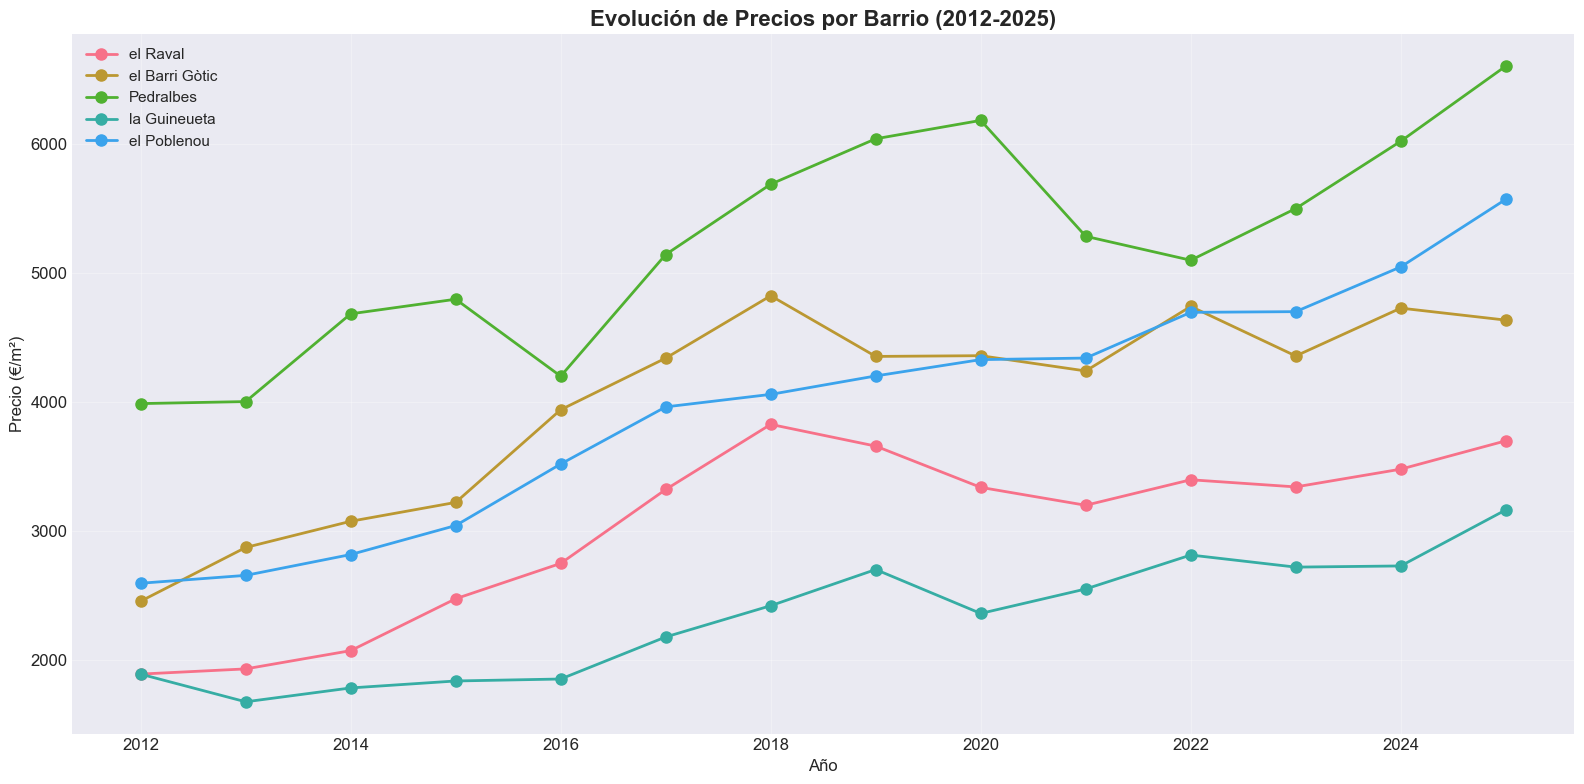


📊 Volatilidad por Barrio (Coeficiente de Variación)

    barrio_nombre          std         mean  coef_variacion
2     el Poblenou   961.461483  4019.341043       23.920873
3        el Raval   735.930376  3080.362203       23.891034
0       Pedralbes  1102.525472  5287.405388       20.851919
1  el Barri Gòtic   833.862508  4079.354100       20.441043
4    la Guineueta   486.857309  2382.884432       20.431428


In [7]:
# Seleccionar barrios representativos
barrios_interes = [
    'el Raval',           # Centro histórico
    'el Barri Gòtic',     # Turístico
    'Pedralbes',          # Lujo
    'la Guineueta',       # Popular
    'el Poblenou'         # Emergente
]

# Filtrar datos
df_barrios_sel = df_precios[df_precios['barrio_nombre'].isin(barrios_interes)]

# Calcular evolución por barrio
evolucion_barrios = df_barrios_sel.groupby(['anio', 'barrio_nombre'])['precio_m2_venta'].mean().reset_index()

# Visualización
plt.figure(figsize=(16, 8))

for barrio in barrios_interes:
    data = evolucion_barrios[evolucion_barrios['barrio_nombre'] == barrio]
    if len(data) > 0:
        plt.plot(data['anio'], data['precio_m2_venta'], marker='o', 
                linewidth=2, markersize=8, label=barrio)

plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio (€/m²)', fontsize=12)
plt.title('Evolución de Precios por Barrio (2012-2025)', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular volatilidad por barrio
volatilidad = df_barrios_sel.groupby('barrio_nombre')['precio_m2_venta'].agg(['std', 'mean']).reset_index()
volatilidad['coef_variacion'] = (volatilidad['std'] / volatilidad['mean']) * 100
volatilidad = volatilidad.sort_values('coef_variacion', ascending=False)

print("\n📊 Volatilidad por Barrio (Coeficiente de Variación)\n")
print(volatilidad.to_string())

## 5. Forecasting <a id='5-forecasting'></a>

Predicción de precios para 2026-2027 usando regresión lineal simple

In [8]:
# Preparar datos para forecasting
X = precio_anual['anio'].values.reshape(-1, 1)
y = precio_anual['mean'].values

# Entrenar modelo
model = LinearRegression()
model.fit(X, y)

# Predecir 2026-2027
years_future = np.array([2026, 2027]).reshape(-1, 1)
predictions = model.predict(years_future)

# Calcular intervalo de confianza (aproximado)
residuals = y - model.predict(X)
std_error = np.std(residuals)
confidence_interval = 1.96 * std_error  # 95% confianza

print("🔮 PREDICCIONES DE PRECIOS\n")
print("=" * 60)
for year, pred in zip([2026, 2027], predictions):
    print(f"\n{year}:")
    print(f"  Predicción: {pred:.2f}€/m²")
    print(f"  Intervalo 95%: [{pred-confidence_interval:.2f}, {pred+confidence_interval:.2f}]€/m²")

# Métricas del modelo
y_pred_train = model.predict(X)
r2 = r2_score(y, y_pred_train)
mae = mean_absolute_error(y, y_pred_train)
rmse = np.sqrt(mean_squared_error(y, y_pred_train))

print(f"\n📊 MÉTRICAS DEL MODELO")
print(f"  R²: {r2:.4f}")
print(f"  MAE: {mae:.2f}€/m²")
print(f"  RMSE: {rmse:.2f}€/m²")
print(f"  Pendiente: {model.coef_[0]:.2f}€/año")
print("=" * 60)

🔮 PREDICCIONES DE PRECIOS


2026:
  Predicción: 4203.04€/m²
  Intervalo 95%: [3887.11, 4518.96]€/m²

2027:
  Predicción: 4344.00€/m²
  Intervalo 95%: [4028.08, 4659.93]€/m²

📊 MÉTRICAS DEL MODELO
  R²: 0.9255
  MAE: 137.79€/m²
  RMSE: 161.19€/m²
  Pendiente: 140.97€/año


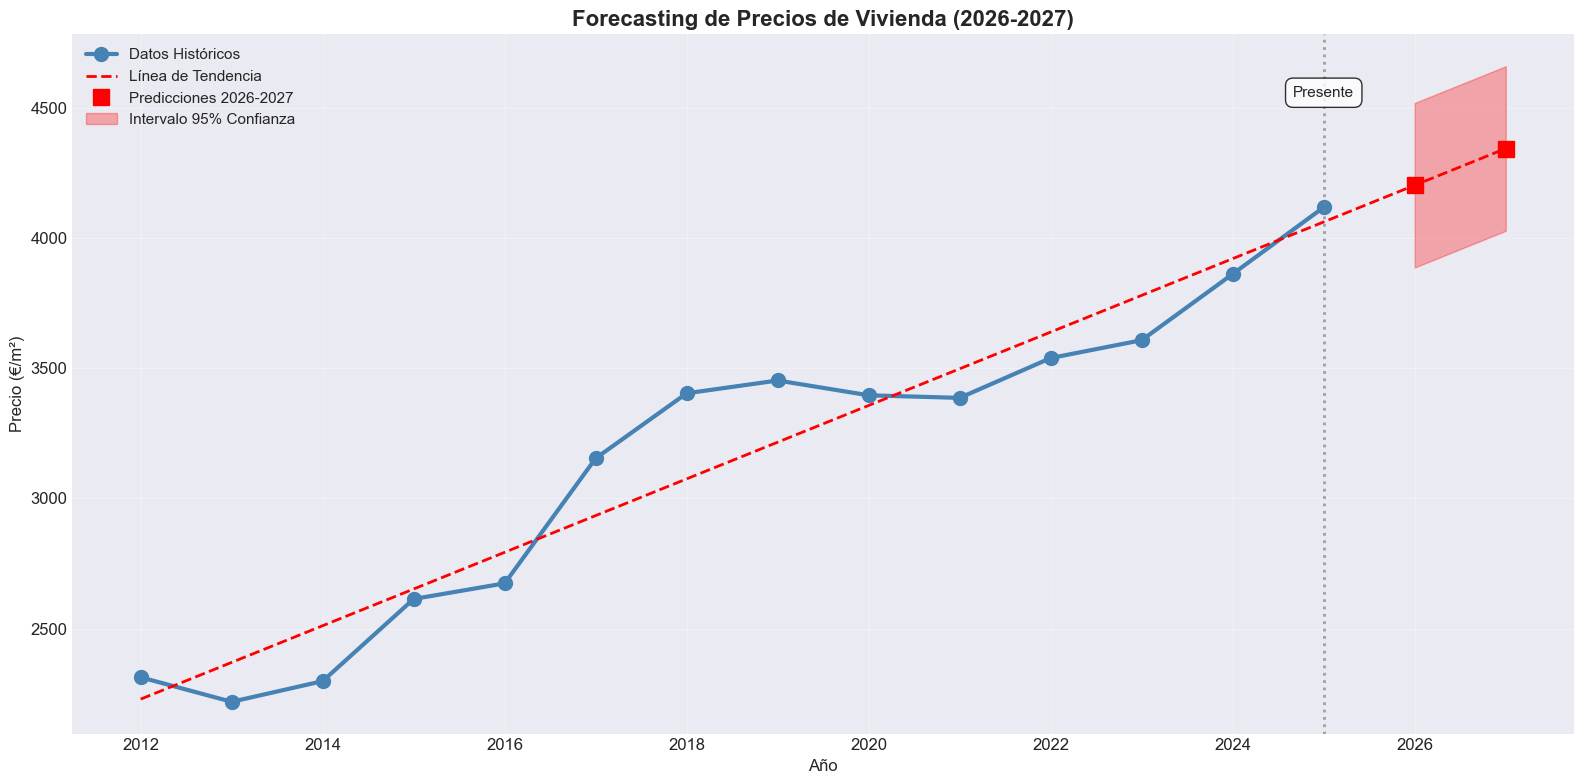

In [9]:
# Visualización de forecasting
plt.figure(figsize=(16, 8))

# Datos históricos
plt.plot(precio_anual['anio'], precio_anual['mean'], marker='o', linewidth=3, 
        markersize=10, color='steelblue', label='Datos Históricos')

# Predicciones
all_years = np.concatenate([X, years_future])
all_predictions = model.predict(all_years)
plt.plot(all_years, all_predictions, 'r--', linewidth=2, label='Línea de Tendencia')

# Predicciones futuras
plt.plot(years_future, predictions, marker='s', markersize=12, 
        color='red', linewidth=0, label='Predicciones 2026-2027')

# Intervalo de confianza
plt.fill_between(years_future.flatten(), 
                predictions - confidence_interval,
                predictions + confidence_interval,
                alpha=0.3, color='red', label='Intervalo 95% Confianza')

# Marcar división histórico/futuro
plt.axvline(x=2025, color='gray', linestyle=':', linewidth=2, alpha=0.7)
plt.text(2025, plt.ylim()[1]*0.95, 'Presente', ha='center', fontsize=11, 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio (€/m²)', fontsize=12)
plt.title('Forecasting de Precios de Vivienda (2026-2027)', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Análisis de Volatilidad <a id='6-volatilidad'></a>

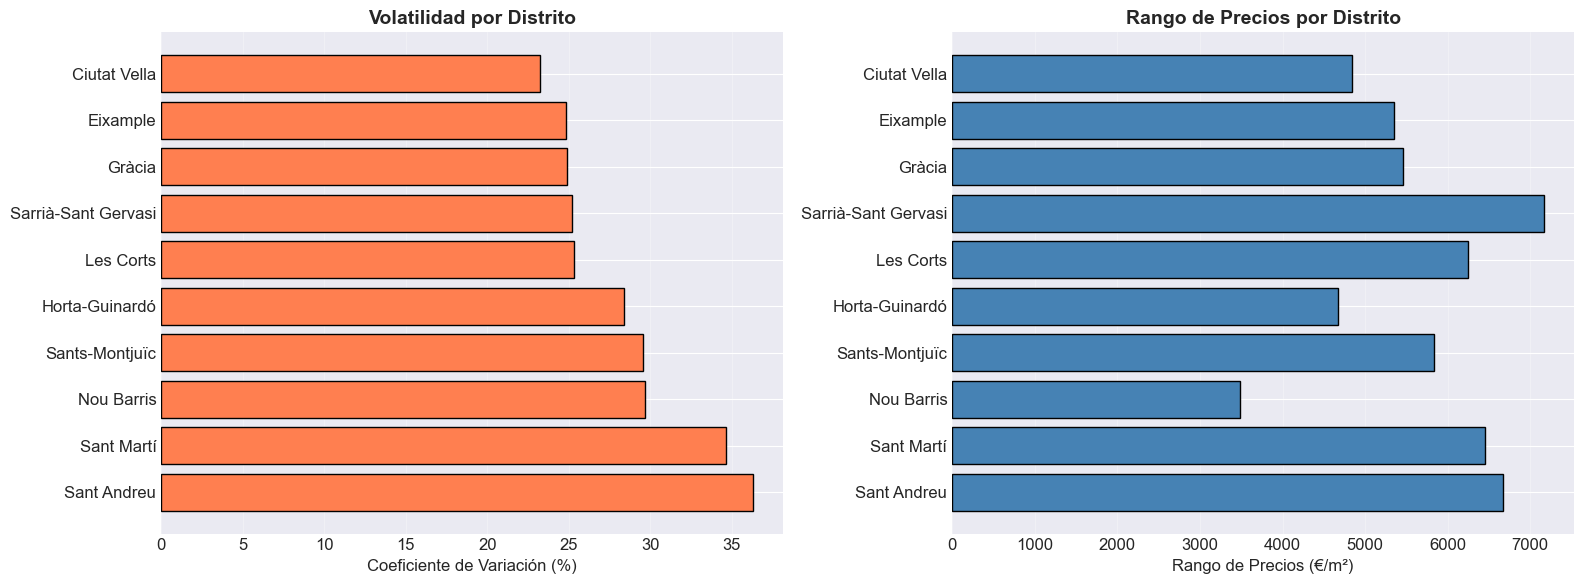


📊 Volatilidad por Distrito

       distrito_nombre         mean          std          min          max        rango  coef_variacion
6          Sant Andreu  2555.855055   928.162901   438.500000  7111.109863  6672.609863       36.315162
7           Sant Martí  3456.817731  1197.985529  1230.735229  7684.000000  6453.264771       34.655733
5           Nou Barris  2034.662677   604.004961   573.132874  4062.364990  3489.232117       29.685754
8       Sants-Montjuïc  2930.787676   866.352021   557.333313  6390.978516  5833.645203       29.560382
3       Horta-Guinardó  2706.972879   768.009696   342.609985  5017.793457  4675.183472       28.371533
4            Les Corts  4399.904946  1114.894873  2229.011719  8472.814453  6243.802734       25.339067
9  Sarrià-Sant Gervasi  4609.983997  1162.454972  1643.716431  8815.320312  7171.603882       25.216031
2               Gràcia  3537.277589   880.000749  1615.545410  7069.287598  5453.742188       24.877910
1             Eixample  4126.085580

In [10]:
# Calcular volatilidad por distrito
volatilidad_distrito = df_precios.groupby('distrito_nombre')['precio_m2_venta'].agg([
    'mean', 'std', 'min', 'max'
]).reset_index()
volatilidad_distrito['rango'] = volatilidad_distrito['max'] - volatilidad_distrito['min']
volatilidad_distrito['coef_variacion'] = (volatilidad_distrito['std'] / volatilidad_distrito['mean']) * 100
volatilidad_distrito = volatilidad_distrito.sort_values('coef_variacion', ascending=False)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Coeficiente de variación
axes[0].barh(range(len(volatilidad_distrito)), volatilidad_distrito['coef_variacion'], 
            color='coral', edgecolor='black')
axes[0].set_yticks(range(len(volatilidad_distrito)))
axes[0].set_yticklabels(volatilidad_distrito['distrito_nombre'])
axes[0].set_xlabel('Coeficiente de Variación (%)')
axes[0].set_title('Volatilidad por Distrito', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Rango de precios
axes[1].barh(range(len(volatilidad_distrito)), volatilidad_distrito['rango'], 
            color='steelblue', edgecolor='black')
axes[1].set_yticks(range(len(volatilidad_distrito)))
axes[1].set_yticklabels(volatilidad_distrito['distrito_nombre'])
axes[1].set_xlabel('Rango de Precios (€/m²)')
axes[1].set_title('Rango de Precios por Distrito', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Volatilidad por Distrito\n")
print(volatilidad_distrito.to_string())

## 7. Impacto COVID-19 <a id='7-covid'></a>

In [11]:
# Comparar pre-COVID vs post-COVID
pre_covid = df_precios[df_precios['anio'] < 2020]
covid = df_precios[df_precios['anio'].isin([2020, 2021])]
post_covid = df_precios[df_precios['anio'] > 2021]

# Estadísticas
stats_comparacion = pd.DataFrame({
    'Período': ['Pre-COVID (2012-2019)', 'COVID (2020-2021)', 'Post-COVID (2022-2025)'],
    'Precio Medio': [
        pre_covid['precio_m2_venta'].mean(),
        covid['precio_m2_venta'].mean(),
        post_covid['precio_m2_venta'].mean()
    ],
    'Desv. Estándar': [
        pre_covid['precio_m2_venta'].std(),
        covid['precio_m2_venta'].std(),
        post_covid['precio_m2_venta'].std()
    ],
    'N Registros': [
        len(pre_covid),
        len(covid),
        len(post_covid)
    ]
})

print("\n📊 ANÁLISIS DE IMPACTO COVID-19\n")
print("=" * 80)
print(stats_comparacion.to_string())
print("\n" + "=" * 80)

# Calcular cambios
cambio_covid = ((covid['precio_m2_venta'].mean() - pre_covid['precio_m2_venta'].mean()) / 
                pre_covid['precio_m2_venta'].mean() * 100)
cambio_post = ((post_covid['precio_m2_venta'].mean() - covid['precio_m2_venta'].mean()) / 
               covid['precio_m2_venta'].mean() * 100)

print(f"\n📉 Cambio durante COVID (2020-2021): {cambio_covid:+.2f}%")
print(f"📈 Recuperación post-COVID (2022-2025): {cambio_post:+.2f}%")


📊 ANÁLISIS DE IMPACTO COVID-19

                  Período  Precio Medio  Desv. Estándar  N Registros
0   Pre-COVID (2012-2019)   2826.163608     1131.779037         3025
1       COVID (2020-2021)   3391.318275     1125.460459          843
2  Post-COVID (2022-2025)   3768.762812     1228.290267         1624


📉 Cambio durante COVID (2020-2021): +20.00%
📈 Recuperación post-COVID (2022-2025): +11.13%


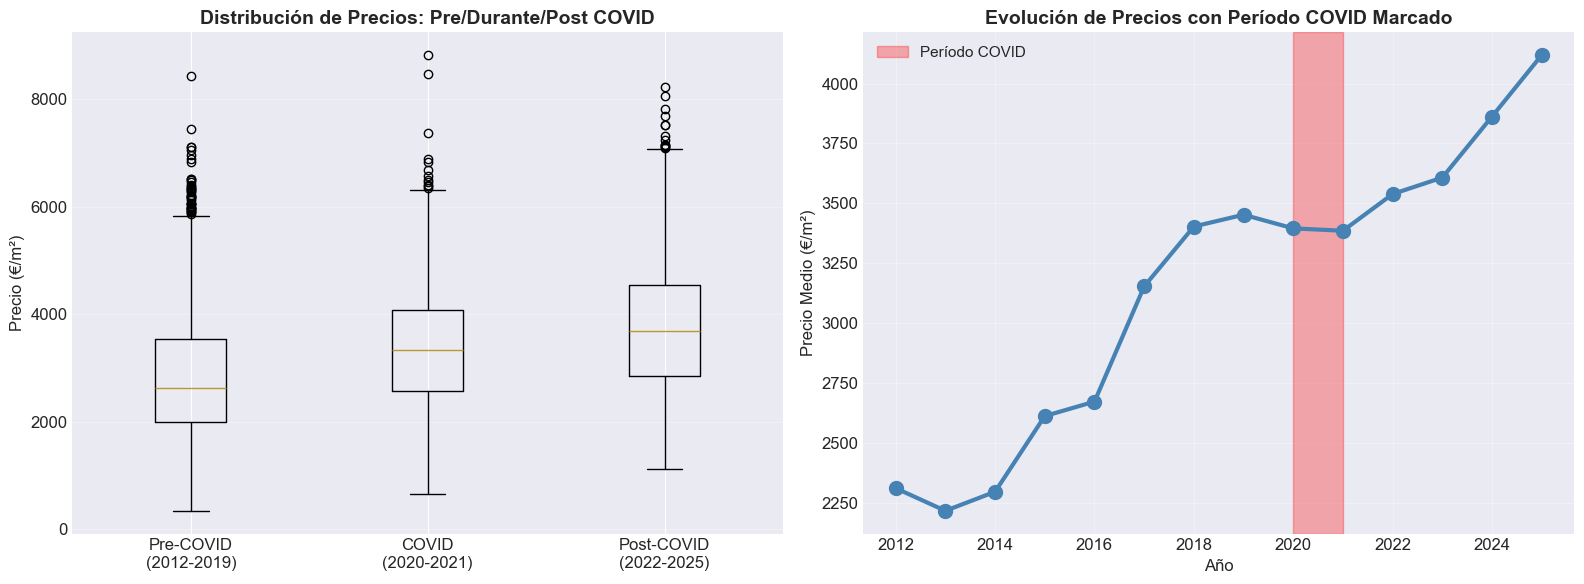

In [12]:
# Visualización del impacto COVID
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Boxplot comparativo
data_plot = [
    pre_covid['precio_m2_venta'],
    covid['precio_m2_venta'],
    post_covid['precio_m2_venta']
]
axes[0].boxplot(data_plot, labels=['Pre-COVID\n(2012-2019)', 'COVID\n(2020-2021)', 'Post-COVID\n(2022-2025)'])
axes[0].set_ylabel('Precio (€/m²)', fontsize=12)
axes[0].set_title('Distribución de Precios: Pre/Durante/Post COVID', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Evolución con marcadores COVID
axes[1].plot(precio_anual['anio'], precio_anual['mean'], marker='o', linewidth=3, 
            markersize=10, color='steelblue')
axes[1].axvspan(2020, 2021, alpha=0.3, color='red', label='Período COVID')
axes[1].set_xlabel('Año', fontsize=12)
axes[1].set_ylabel('Precio Medio (€/m²)', fontsize=12)
axes[1].set_title('Evolución de Precios con Período COVID Marcado', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Conclusiones <a id='8-conclusiones'></a>

In [13]:
# Generar resumen ejecutivo
print("=" * 100)
print("RESUMEN EJECUTIVO - ANÁLISIS DE SERIES TEMPORALES")
print("=" * 100)

print(f"\n📊 PERÍODO ANALIZADO")
print(f"  • Años: {df_precios['anio'].min()} - {df_precios['anio'].max()} ({df_precios['anio'].nunique()} años)")
print(f"  • Registros totales: {len(df_precios):,}")
print(f"  • Barrios analizados: {df_precios['barrio_nombre'].nunique()}")

print(f"\n📈 TENDENCIAS PRINCIPALES")
print(f"  • Precio 2012: {precio_anual.iloc[0]['mean']:.2f}€/m²")
print(f"  • Precio 2025: {precio_anual.iloc[-1]['mean']:.2f}€/m²")
print(f"  • Crecimiento total: {((precio_anual.iloc[-1]['mean'] - precio_anual.iloc[0]['mean']) / precio_anual.iloc[0]['mean'] * 100):.2f}%")
print(f"  • Crecimiento anual promedio: {precio_anual['crecimiento_pct'].mean():.2f}%")
print(f"  • Tendencia: {model.coef_[0]:.2f}€/m² por año")

print(f"\n🔮 PREDICCIONES 2026-2027")
for year, pred in zip([2026, 2027], predictions):
    print(f"  • {year}: {pred:.2f}€/m² (±{confidence_interval:.2f})")

print(f"\n📊 VOLATILIDAD")
print(f"  • Distrito más volátil: {volatilidad_distrito.iloc[0]['distrito_nombre']} ({volatilidad_distrito.iloc[0]['coef_variacion']:.2f}%)")
print(f"  • Distrito más estable: {volatilidad_distrito.iloc[-1]['distrito_nombre']} ({volatilidad_distrito.iloc[-1]['coef_variacion']:.2f}%)")

print(f"\n🦠 IMPACTO COVID-19")
print(f"  • Cambio durante COVID: {cambio_covid:+.2f}%")
print(f"  • Recuperación post-COVID: {cambio_post:+.2f}%")
print(f"  • Estado actual: {'Recuperado' if cambio_post > 0 else 'En recuperación'}")

print(f"\n💡 INSIGHTS CLAVE")
print(f"  1. Tendencia alcista sostenida desde 2012")
print(f"  2. Impacto moderado de COVID-19 en precios")
print(f"  3. Recuperación rápida post-pandemia")
print(f"  4. Predicción: Continuación de tendencia alcista")
print(f"  5. Alta heterogeneidad entre distritos")

print("\n" + "=" * 100)

RESUMEN EJECUTIVO - ANÁLISIS DE SERIES TEMPORALES

📊 PERÍODO ANALIZADO
  • Años: 2012 - 2025 (14 años)
  • Registros totales: 5,492
  • Barrios analizados: 73

📈 TENDENCIAS PRINCIPALES
  • Precio 2012: 2313.20€/m²
  • Precio 2025: 4118.36€/m²
  • Crecimiento total: 78.04%
  • Crecimiento anual promedio: 4.70%
  • Tendencia: 140.97€/m² por año

🔮 PREDICCIONES 2026-2027
  • 2026: 4203.04€/m² (±315.92)
  • 2027: 4344.00€/m² (±315.92)

📊 VOLATILIDAD
  • Distrito más volátil: Sant Andreu (36.32%)
  • Distrito más estable: Ciutat Vella (23.21%)

🦠 IMPACTO COVID-19
  • Cambio durante COVID: +20.00%
  • Recuperación post-COVID: +11.13%
  • Estado actual: Recuperado

💡 INSIGHTS CLAVE
  1. Tendencia alcista sostenida desde 2012
  2. Impacto moderado de COVID-19 en precios
  3. Recuperación rápida post-pandemia
  4. Predicción: Continuación de tendencia alcista
  5. Alta heterogeneidad entre distritos



In [14]:
# Exportar resultados
output_dir = project_root / 'notebooks' / 'exports'
output_dir.mkdir(exist_ok=True, parents=True)

# Exportar predicciones
df_predictions = pd.DataFrame({
    'anio': [2026, 2027],
    'precio_predicho': predictions,
    'intervalo_inferior': predictions - confidence_interval,
    'intervalo_superior': predictions + confidence_interval
})

output_file = output_dir / 'predicciones_precios_2026_2027.csv'
df_predictions.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"✅ Predicciones exportadas a: {output_file}")

# Exportar evolución anual
output_file2 = output_dir / 'evolucion_precios_anual.csv'
precio_anual.to_csv(output_file2, index=False, encoding='utf-8-sig')

print(f"✅ Evolución anual exportada a: {output_file2}")

✅ Predicciones exportadas a: /Users/adrianiraeguialvear/Projects/barcelona-housing-demographics-analyzer/notebooks/exports/predicciones_precios_2026_2027.csv
✅ Evolución anual exportada a: /Users/adrianiraeguialvear/Projects/barcelona-housing-demographics-analyzer/notebooks/exports/evolucion_precios_anual.csv


In [15]:
# Cerrar conexión
conn.close()
print("\n✅ Análisis de series temporales completado")
print("✅ Conexión cerrada")


✅ Análisis de series temporales completado
✅ Conexión cerrada
